# Final Dataset Construction

## Overview

This notebook combines all previously prepared data sources into a single dataset that will be used for model training and evaluation.

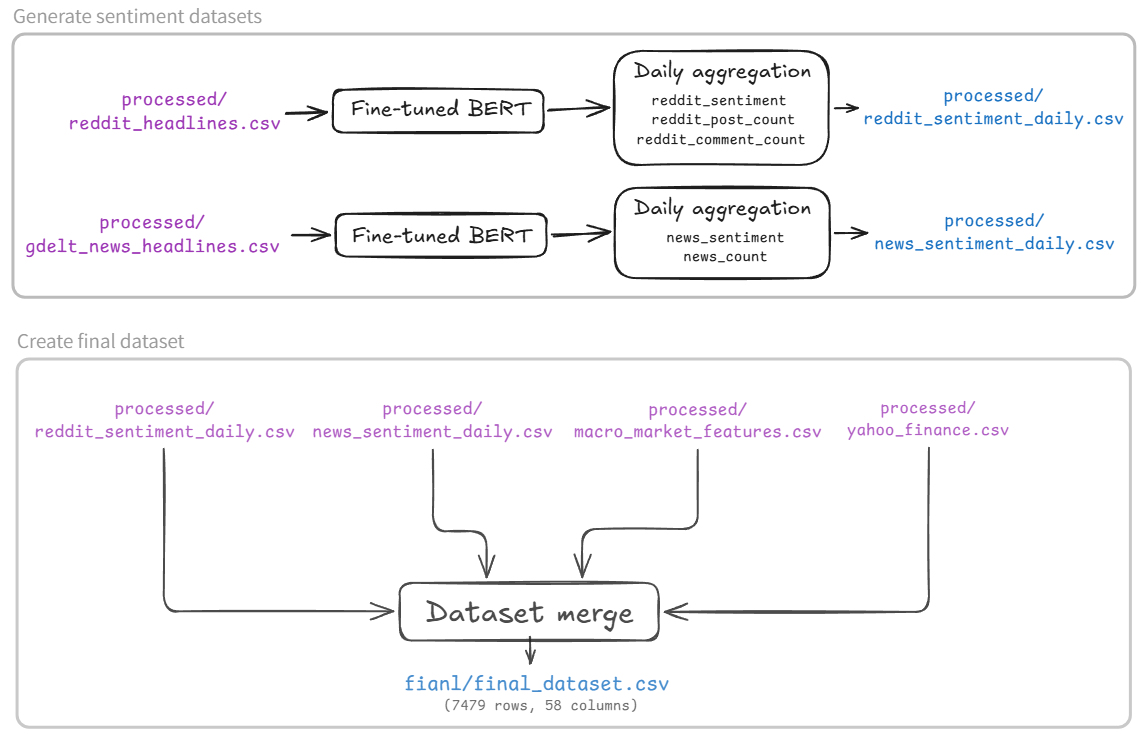

## 1. Configuration

Since BERT inference on ~120,000 texts would be impractically slow on CPU,
this stage was executed in VS Code connected to a Google Colab runtime
via the Colab extension, providing access to a free T4 GPU.
The fine-tuned model and processed datasets are accessed directly
from Google Drive.

In [49]:
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

COMPANIES  = ['NVDA', 'AMD', 'INTC']
BATCH_SIZE = 64
MAX_LENGTH = 128
MODEL_PATH = '/content/drive/MyDrive/diplomski/models/bert_best.pt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

KeyboardInterrupt: 

## 2. Model loading

The fine-tuned BERT model is loaded in two steps. First, the base
`bert-base-uncased` architecture is initialized using `from_pretrained`,
which constructs the model with its original pre-trained weights.
Then, `load_state_dict` replaces those weights with the fine-tuned
weights saved during training (`bert_best.pt`). Finally, the model
is set to evaluation mode via `model.eval()`, which disables dropout
layers that are only active during training.

In [ ]:
label_to_id = {'positive': 0, 'negative': 1, 'neutral': 2}
id_to_label = {0: 'positive', 1: 'negative', 2: 'neutral'}

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    id2label=id_to_label,
    label2id=label_to_id
)

model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)
model = model.to(device)
model.eval()
print('Model loaded!')

Loading tokenizer and model...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!


## 3. Inference function

The `run_inference` function applies the fine-tuned BERT model to a list
of texts and returns a DataFrame with sentiment predictions. Texts are
first tokenized using `BertTokenizer`, which converts them to `input_ids`
and `attention_mask` tensors. The tokenized texts are wrapped in a
`HeadlineDataset` object and processed in batches of 64 via `DataLoader`
to avoid exceeding GPU memory limits. Gradient computation is disabled
with `torch.no_grad()` since it is not required for inference.

For each headline or Reddit post title, the fine-tuned BERT model produces 
three class probabilities: $P(\text{positive})$, $P(\text{negative})$, and 
$P(\text{neutral})$. The sentiment score for a single text is computed as:

$$\text{sentiment\_score} = P(\text{positive}) - P(\text{negative})$$

This yields a continuous value in the range $[-1, 1]$, where values close 
to $1$ indicate strongly positive sentiment, values close to $-1$ indicate 
strongly negative sentiment, and values near $0$ reflect neutral or mixed sentiment.


In [ ]:
class HeadlineDataset(Dataset):
    """
    Simple dataset for inference — wraps tokenized headlines.
    """
    def __init__(self, encodings):
        self.input_ids      = encodings['input_ids']
        self.attention_mask = encodings['attention_mask']

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx]
        }


def run_inference(texts: list[str]) -> pd.DataFrame:
    """
    Runs BERT inference on a list of texts.
    Returns a DataFrame with columns:
        positive, negative, neutral — class probabilities
        label                      — predicted class
        sentiment_score            — P(positive) - P(negative)
    """
    encodings = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )

    dataset = HeadlineDataset(encodings)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    all_probs = []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Inference'):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.vstack(all_probs)

    results = pd.DataFrame({
        'positive':        all_probs[:, 0],
        'negative':        all_probs[:, 1],
        'neutral':         all_probs[:, 2],
        'label':           [id_to_label[i] for i in all_probs.argmax(axis=1)],
        'sentiment_score': all_probs[:, 0] - all_probs[:, 1]
    })

    return results

## 4. Reddit sentiment

The fine-tuned BERT model is applied to all Reddit post titles to generate
per-post sentiment scores. The resulting sentiment labels and scores are
added to the Reddit dataset and subsequently aggregated to the trading-day
level in the next step.

In [ ]:
reddit_df = pd.read_csv('/content/drive/MyDrive/diplomski/datasets/processed/reddit_headlines.csv')
reddit_df['trading_date'] = pd.to_datetime(reddit_df['trading_date'])
print(f'Reddit shape: {reddit_df.shape}')

In [ ]:
print('\nRunning BERT inference on Reddit titles:')
reddit_results = run_inference(reddit_df['title'].tolist())

In [ ]:
# Add results to dataframe
reddit_df['positive']        = reddit_results['positive'].values
reddit_df['negative']        = reddit_results['negative'].values
reddit_df['neutral']         = reddit_results['neutral'].values
reddit_df['label']           = reddit_results['label'].values
reddit_df['sentiment_score'] = reddit_results['sentiment_score'].values

print(f'\nSentiment distribution:')
print(reddit_df['label'].value_counts())
print(f'\nSentiment score stats:')
print(reddit_df['sentiment_score'].describe().round(4))

Loading Reddit data...
Reddit shape: (59673, 9)
Columns: ['post_id', 'date', 'subreddit', 'title', 'num_comments', 'company', 'source_type', 'trading_date', 'month']

Running BERT inference on Reddit titles...


Inference: 100%|██████████| 933/933 [07:15<00:00,  2.14it/s]



Sentiment distribution:
label
neutral     46146
positive     8950
negative     4577
Name: count, dtype: int64

Sentiment score stats:
count    59673.0000
mean         0.0755
std          0.4347
min         -0.9974
25%         -0.0016
50%          0.0010
75%          0.0304
max          0.9968
Name: sentiment_score, dtype: float64


The post-level sentiment scores are aggregated to the trading-day level by grouping on `trading_date` and `company`.
For each group, three features are computed: `reddit_sentiment` as the mean sentiment score across all posts,
`reddit_post_count` as the total number of posts, and `reddit_comment_count` as the total number of comments.

$$\text{reddit\_sentiment} = \frac{1}{N} \sum_{i=1}^{N} \left( P_i(\text{positive}) - P_i(\text{negative}) \right)$$

$$\text{reddit\_post\_count} = N$$

$$\text{reddit\_comment\_count} = \sum_{i=1}^{N} c_i$$

where $N$ is the number of posts attributed to that company on that trading day and $c_i$ is the number of comments on post $i$.


In [ ]:
reddit_daily = (
    reddit_df
    .groupby(['trading_date', 'company'])
    .agg(
        reddit_sentiment      = ('sentiment_score', 'mean'),
        reddit_post_count     = ('title',           'count'),
        reddit_comment_count  = ('num_comments',    'sum')
    )
    .reset_index()
)

print(f'Reddit daily shape: {reddit_daily.shape}')

Reddit daily shape: (5967, 5)

Sample:


,trading_date,company,reddit_sentiment,reddit_post_count,reddit_comment_count
0,2016-04-28,AMD,0.000322,4,135
1,2016-04-29,AMD,-0.000272,1,0
2,2016-04-29,INTC,0.048528,1,13
3,2016-04-29,NVDA,-0.001378,2,13
4,2016-05-04,NVDA,0.000235,1,28


In [ ]:
reddit_daily.head()

## 5. News sentiment

The same inference procedure is applied to financial news headlines
from the GDELT dataset. Sentiment labels and scores are added to the
news dataset and subsequently aggregated to the trading-day level.

In [1]:
news_df = pd.read_csv('/content/drive/MyDrive/diplomski/datasets/processed/gdelt_news_headlines.csv')
news_df['trading_date'] = pd.to_datetime(news_df['trading_date'])
print(f'News shape: {news_df.shape}')

NameError: name 'pd' is not defined

In [ ]:
# Run inference
print('\nRunning BERT inference on news headlines...')
news_results = run_inference(news_df['headline'].tolist())

In [ ]:
# Add results to dataframe
news_df['positive']        = news_results['positive'].values
news_df['negative']        = news_results['negative'].values
news_df['neutral']         = news_results['neutral'].values
news_df['label']           = news_results['label'].values
news_df['sentiment_score'] = news_results['sentiment_score'].values

print(f'\nSentiment distribution:')
print(news_df['label'].value_counts())
print(f'\nSentiment score stats:')
print(news_df['sentiment_score'].describe().round(4))

Loading news data...
News shape: (67729, 6)

Running BERT inference on news headlines...


Inference: 100%|██████████| 1059/1059 [08:49<00:00,  2.00it/s]



Sentiment distribution:
label
neutral     44045
positive    14816
negative     8868
Name: count, dtype: int64

Sentiment score stats:
count    67729.0000
mean         0.0888
std          0.5521
min         -0.9974
25%         -0.0006
50%          0.0020
75%          0.1800
max          0.9968
Name: sentiment_score, dtype: float64


The headline-level sentiment scores are aggregated to the trading-day
level by grouping on `trading_date` and `company`. Two features are
computed: `news_sentiment` as the mean sentiment score across all
headlines, and `news_count` as the total number of articles.

$$\text{news\_sentiment} = \frac{1}{N} \sum_{i=1}^{N} \left( P_i(\text{positive}) - P_i(\text{negative}) \right)$$

$$\text{news\_count} = N$$

where $N$ is the number of articles attributed to that company on that trading day.

In [ ]:
news_daily = (
    news_df
    .groupby(['trading_date', 'company'])
    .agg(
        news_sentiment = ('sentiment_score', 'mean'),
        news_count     = ('headline',        'count')
    )
    .reset_index()
)

print(f'News daily shape: {news_daily.shape}')

News daily shape: (6559, 4)

Sample:


,trading_date,company,news_sentiment,news_count
0,2016-04-28,AMD,0.001206,1
1,2016-04-28,INTC,-0.021998,25
2,2016-04-28,NVDA,-0.050354,2
3,2016-04-29,AMD,0.042571,2
4,2016-04-29,INTC,-0.136787,43


In [ ]:
news_daily.head()

Both aggregated sentiment datasets are saved to Google Drive and
downloaded to the local environment for the final
dataset merge.

In [ ]:
os.makedirs('/content/drive/MyDrive/diplomski/datasets/processed', exist_ok=True)

reddit_daily.to_csv(
    '/content/drive/MyDrive/diplomski/datasets/processed/reddit_sentiment_daily.csv',
    index=False
)

news_daily.to_csv(
    '/content/drive/MyDrive/diplomski/datasets/processed/news_sentiment_daily.csv',
    index=False
)

Reddit daily sentiment saved!
News daily sentiment saved!


## 6. Dataset merge

This section runs in the local environment. All four processed datasets
are loaded and merged into a single company-level daily dataset using
Yahoo Finance as the base, since it defines the set of valid trading days.
Reddit and news sentiment are joined via left merge, meaning that trading
days without sentiment data retain `NaN` values, which will be handled
in the subsequent preprocessing notebook.

In [1]:
import pandas as pd
import mlflow
import os

OUTPUT_DIR = "datasets/final"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PATH = f"{OUTPUT_DIR}/final_dataset.csv"


yahoo_df = pd.read_csv('datasets/processed/yahoo_finance.csv')
macro_df = pd.read_csv('datasets/processed/macro_market_features.csv')
reddit_sentiment_df = pd.read_csv('datasets/processed/reddit_sentiment_daily.csv')
news_sentiment_df   = pd.read_csv('datasets/processed/news_sentiment_daily.csv')

In [2]:
yahoo_df['date']                    = pd.to_datetime(yahoo_df['date'])
macro_df['date']                    = pd.to_datetime(macro_df['date'])
reddit_sentiment_df['trading_date'] = pd.to_datetime(reddit_sentiment_df['trading_date'])
news_sentiment_df['trading_date']   = pd.to_datetime(news_sentiment_df['trading_date'])

print(f'Yahoo Finance shape  : {yahoo_df.shape}')
print(f'Macro features shape : {macro_df.shape}')
print(f'Reddit daily shape   : {reddit_sentiment_df.shape}')
print(f'News daily shape     : {news_sentiment_df.shape}')

Yahoo Finance shape  : (7413, 46)
Macro features shape : (7413, 16)
Reddit daily shape   : (5967, 5)
News daily shape     : (6559, 4)


In [3]:
# Rename columns for consistency 
yahoo_df = yahoo_df.rename(columns={'ticker': 'company'})
reddit_sentiment_df = reddit_sentiment_df.rename(columns={'trading_date': 'date'})
news_sentiment_df   = news_sentiment_df.rename(columns={'trading_date': 'date'})

In [4]:
# already aligned by date/company
df = yahoo_df.merge(
    macro_df,
    on=['date', 'company'],
    how='inner'
)

print(f'After Yahoo and Macro merge: {df.shape}')

After Yahoo and Macro merge: (7413, 60)


In [5]:
df = df.merge(
    reddit_sentiment_df[['date', 'company', 'reddit_sentiment', 'reddit_post_count', 'reddit_comment_count']],
    on=['date', 'company'],
    how='left'
)

print(f'After Reddit merge: {df.shape}')

After Reddit merge: (7413, 63)


In [6]:
df = df.merge(
    news_sentiment_df[['date', 'company', 'news_sentiment', 'news_count']],
    on=['date', 'company'],
    how='left'
)

print(f'After News merge: {df.shape}')

After News merge: (7413, 65)


In [7]:
print(f'\nFinal shape: {df.shape}')
print(f'\nMissing values per sentiment column:')
print(df[['reddit_sentiment', 'reddit_post_count', 'reddit_comment_count', 
          'news_sentiment', 'news_count']].isna().sum())


Final shape: (7413, 65)

Missing values per sentiment column:
reddit_sentiment        1477
reddit_post_count       1477
reddit_comment_count    1477
news_sentiment           916
news_count               916
dtype: int64


In [24]:
df.head()

,date,company,open,high,low,close,adj_close,volume,sma_10,sma_20,...,HML,RMW,CMA,RF,Mom,reddit_sentiment,reddit_post_count,reddit_comment_count,news_sentiment,news_count
0,2016-05-31,NVDA,1.1525,1.1705,1.15175,1.16800,1.146681,412524000,1.095031,0.996322,...,-0.37,-0.20,-0.32,0.0,-0.61,NaN,NaN,NaN,NaN,NaN
1,2016-06-01,NVDA,1.1625,1.1815,1.15900,1.17025,1.148890,387132000,1.106418,1.010228,...,-0.21,-0.28,0.06,0.0,-0.03,0.273954,3.0,41.0,0.097645,6.0
2,2016-06-02,NVDA,1.1765,1.1885,1.16500,1.17850,1.156990,329208000,1.115971,1.025531,...,-0.58,-0.20,-0.04,0.0,-0.60,0.000035,1.0,92.0,-0.092225,8.0
3,2016-06-03,NVDA,1.1670,1.1685,1.14150,1.16200,1.140791,461076000,1.123439,1.039767,...,-0.07,0.52,0.14,0.0,0.67,0.010668,2.0,63.0,0.062620,8.0
4,2016-06-06,NVDA,1.1650,1.1740,1.15000,1.15600,1.134900,322512000,1.128409,1.053268,...,0.31,-0.18,-0.08,0.0,-1.31,NaN,NaN,NaN,-0.052165,13.0


In [8]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("final_dataset_construction")

with mlflow.start_run(run_name="dataset_merge"):

    # Parameters
    mlflow.log_param("companies", "NVDA, AMD, INTC")
    mlflow.log_param("sources", "yahoo_finance, macro_market_features, reddit_sentiment, news_sentiment")

    # Metrics
    mlflow.log_metric("total_rows", len(df))
    mlflow.log_metric("total_features", len(df.columns))

    for company in ['NVDA', 'AMD', 'INTC']:
        subset = df[df['company'] == company]
        mlflow.log_metric(f"rows_{company}", len(subset))

    mlflow.log_metric("missing_reddit_sentiment", int(df['reddit_sentiment'].isna().sum()))
    mlflow.log_metric("missing_news_sentiment",   int(df['news_sentiment'].isna().sum()))

    df.to_csv(OUTPUT_PATH, index=False)

    print(f"Dataset saved : {OUTPUT_PATH}")
    print("MLflow run    : completed")

2026/06/05 13:20:17 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



Dataset saved : datasets/final/final_dataset.csv
MLflow run    : completed
